# EDA: Deepfake Detection — Final v5

**Финальный разведочный анализ данных для ВКР**  
**Тема:** Пространственно-временной анализ видеоданных для детекции deepfake  
**Автор:** Торопов А.  
**Дата:** 2026-03

---

## Объект анализа

Анализируются **предобработанные** (preprocessed) датасеты — именно те данные,
на которых обучается модель:

| Датасет | Описание | Preprocessing |
|---------|----------|---------------|
| **DFDC02** | DeepFake Detection Challenge, часть 02 | MTCNN → T кадров → face crops |
| **DFD01** | DeepFakeDetection (Google/FaceForensics++) | MTCNN → T кадров → face crops |

**Preprocessing pipeline:** `preprocess_videos.py`  
**Face detector:** MTCNN (facenet-pytorch)  
**Кадров на видео (T):** 16  

### Важно
- Анализ проводится на **preprocessed данных** (face crops), а не на raw видео
- Все графики и статистики отражают то, что реально видит модель при обучении
- Оба датасета используются для **совместного обучения** (multi-dataset training)

---
## 0. Конфигурация и импорты

In [4]:
from __future__ import annotations

import os
import sys
import json
import hashlib
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy import stats as sp_stats

warnings.filterwarnings("ignore", category=UserWarning)

# ── Style ──
plt.rcParams.update({
    "figure.figsize": (14, 5),
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "sans-serif",
})
sns.set_style("whitegrid")

# ── Paths ──
# Автоматический поиск preprocessed данных
PROJECT_ROOT = Path(".").resolve().parent  # EDA/ -> project root
DATA_ROOT = PROJECT_ROOT / "data" / "preprocessed_data"

DATASETS = {}
for d in sorted(DATA_ROOT.iterdir()) if DATA_ROOT.exists() else []:
    if d.is_dir() and "preprocessed" in d.name.lower():
        DATASETS[d.name] = d

print(f"Project root: {PROJECT_ROOT}")
print(f"Data root:    {DATA_ROOT}")
print(f"Datasets found: {len(DATASETS)}")
for name, path in DATASETS.items():
    print(f"  {name} -> {path}")

# ── Output dirs ──
REPORT_DIR = Path("reports_v5")
PLOTS_DIR = REPORT_DIR / "plots"
TABLES_DIR = REPORT_DIR / "tables"
for d in [REPORT_DIR, PLOTS_DIR, TABLES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Config (должен совпадать с config.py) ──
NUM_FRAMES = 16
SPATIAL_SIZE = 224
TEMPORAL_SIZE = 128
SEED = 42
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15
FACE_DETECTOR = "MTCNN (facenet-pytorch)"

print(f"\nConfig: T={NUM_FRAMES}, spatial={SPATIAL_SIZE}, temporal={TEMPORAL_SIZE}, seed={SEED}")
print(f"Face detector: {FACE_DETECTOR}")

Project root: .
Data root:    ./data/preprocessed_data
Datasets found: 2
  preprocessed_DFD01_16 -> ./data/preprocessed_data/preprocessed_DFD01_16
  preprocessed_DFDC02_16 -> ./data/preprocessed_data/preprocessed_DFDC02_16

Config: T=16, spatial=224, temporal=128, seed=42
Face detector: MTCNN (facenet-pytorch)


---
## 1. Инвентаризация (Inventory)

Строим полный индекс всех видео и кадров в preprocessed датасетах.

In [7]:
def build_inventory(datasets: dict) -> pd.DataFrame:
    """Строит инвентаризацию preprocessed датасетов."""
    rows = []
    for ds_name, ds_path in datasets.items():
        for label_dir in ["real", "fake"]:
            label_path = ds_path / label_dir
            if not label_path.exists():
                continue
            label_int = 0 if label_dir == "real" else 1
            for video_dir in sorted(label_path.iterdir()):
                if not video_dir.is_dir():
                    continue
                frames = sorted([
                    f for f in video_dir.iterdir()
                    if f.suffix.lower() in {".jpg", ".jpeg", ".png"}
                ])
                rows.append({
                    "dataset": ds_name,
                    "video_id": video_dir.name,
                    "label": label_int,
                    "label_name": label_dir,
                    "n_frames": len(frames),
                    "path": str(video_dir),
                    "first_frame": str(frames[0]) if frames else None,
                })
    return pd.DataFrame(rows)

df_inv = build_inventory(DATASETS)
print(f"Всего видео: {len(df_inv)}")
print(f"\nПо датасетам и классам:")
ct = pd.crosstab(df_inv["dataset"], df_inv["label_name"], margins=True)
print(ct)
ct.to_csv(TABLES_DIR / "01_inventory_crosstab.csv")

# Ratio per dataset
print("\nДисбаланс по датасетам:")
for ds in df_inv["dataset"].unique():
    sub = df_inv[df_inv["dataset"] == ds]
    n_real = (sub["label"] == 0).sum()
    n_fake = (sub["label"] == 1).sum()
    ratio = max(n_real, n_fake) / max(min(n_real, n_fake), 1)
    print(f"  {ds}: real={n_real}, fake={n_fake}, ratio={ratio:.2f}:1")

Всего видео: 6724

По датасетам и классам:
label_name              fake  real   All
dataset                                 
preprocessed_DFD01_16   3068   363  3431
preprocessed_DFDC02_16  1566  1727  3293
All                     4634  2090  6724

Дисбаланс по датасетам:
  preprocessed_DFD01_16: real=363, fake=3068, ratio=8.45:1
  preprocessed_DFDC02_16: real=1727, fake=1566, ratio=1.10:1


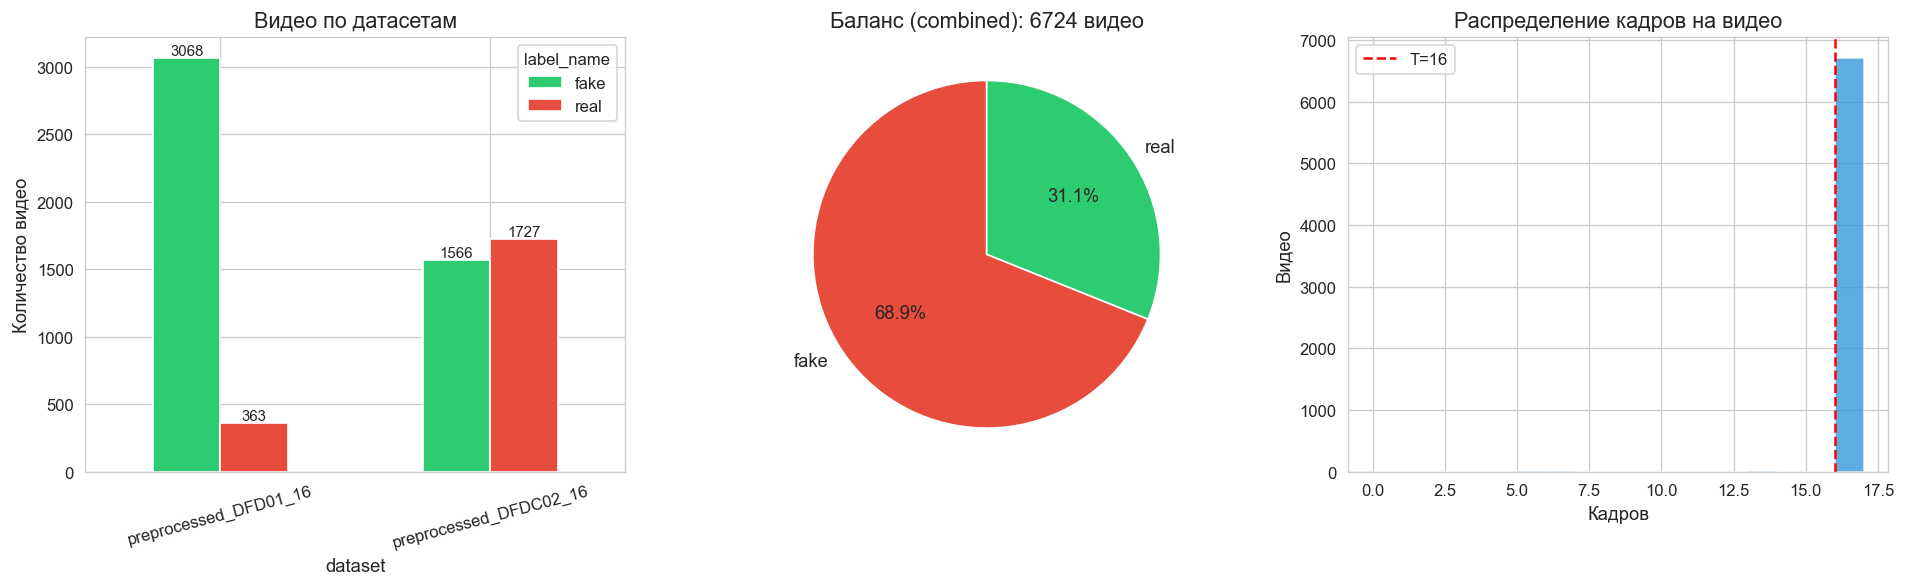


Видео с < 16 кадрами: 12 (0.2%)
                    dataset                              video_id label_name  \
407   preprocessed_DFD01_16  01_09__secret_conversation__SJZRV69J       fake   
432   preprocessed_DFD01_16  01_11__secret_conversation__WIZ7GKOD       fake   
474   preprocessed_DFD01_16  01_20__secret_conversation__FW94AIMJ       fake   
1707  preprocessed_DFD01_16  12_06__secret_conversation__F3I4PDYF       fake   
1740  preprocessed_DFD01_16  12_13__secret_conversation__2TM4IFSF       fake   
1761  preprocessed_DFD01_16  12_15__secret_conversation__N0SRODQD       fake   
1778  preprocessed_DFD01_16  12_20__secret_conversation__B0X1CGG2       fake   
1779  preprocessed_DFD01_16  12_20__secret_conversation__VD7BCF1U       fake   
1787  preprocessed_DFD01_16  12_21__secret_conversation__J54W3PV1       fake   
2996  preprocessed_DFD01_16  24_19__secret_conversation__NPZW2Z9L       fake   

      n_frames  
407         13  
432         12  
474         13  
1707         6  
1

In [8]:
# ── Визуализация: inventory ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Videos per dataset
ds_counts = df_inv.groupby(["dataset", "label_name"]).size().unstack(fill_value=0)
ds_counts.plot.bar(ax=axes[0], color=["#2ecc71", "#e74c3c"])
axes[0].set_title("Видео по датасетам")
axes[0].set_ylabel("Количество видео")
axes[0].tick_params(axis="x", rotation=15)
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=9)

# 2. Combined balance
combined = df_inv["label_name"].value_counts()
colors = ["#2ecc71" if x == "real" else "#e74c3c" for x in combined.index]
axes[1].pie(combined, labels=combined.index, autopct="%1.1f%%", colors=colors,
            startangle=90, textprops={"fontsize": 11})
axes[1].set_title(f"Баланс (combined): {combined.sum()} видео")

# 3. Frames per video distribution
axes[2].hist(df_inv["n_frames"], bins=range(0, df_inv["n_frames"].max() + 2),
             color="#3498db", edgecolor="white", alpha=0.8)
axes[2].axvline(NUM_FRAMES, color="red", linestyle="--", label=f"T={NUM_FRAMES}")
axes[2].set_title("Распределение кадров на видео")
axes[2].set_xlabel("Кадров")
axes[2].set_ylabel("Видео")
axes[2].legend()

fig.tight_layout()
fig.savefig(PLOTS_DIR / "01_inventory.png", dpi=150, bbox_inches="tight")
plt.show()

# Видео с недостаточным числом кадров
short = df_inv[df_inv["n_frames"] < NUM_FRAMES]
print(f"\nВидео с < {NUM_FRAMES} кадрами: {len(short)} ({len(short)/len(df_inv)*100:.1f}%)")
if len(short) > 0:
    print(short[["dataset", "video_id", "label_name", "n_frames"]].head(10))

---
## 2. Качество изображений (Frame Quality)

Анализируем качество face crops: размер, яркость, контраст, резкость, энтропия.  
Это то, что реально видит модель.

In [10]:
def compute_frame_quality(frame_path: str) -> dict:
    """Вычисляет метрики качества одного кадра."""
    try:
        img = Image.open(frame_path).convert("RGB")
        arr = np.array(img, dtype=np.float32)
        gray = np.mean(arr, axis=2)
        
        # Laplacian variance (резкость)
        # Простая аппроксимация через разности
        lap = (
            gray[:-2, 1:-1] + gray[2:, 1:-1] +
            gray[1:-1, :-2] + gray[1:-1, 2:] -
            4 * gray[1:-1, 1:-1]
        )
        
        return {
            "width": img.size[0],
            "height": img.size[1],
            "brightness": float(np.mean(gray)),
            "contrast": float(np.std(gray)),
            "sharpness": float(np.var(lap)),
            "entropy": float(sp_stats.entropy(np.histogram(gray, bins=64)[0] + 1e-10)),
            "valid": True,
        }
    except Exception as e:
        return {"valid": False, "error": str(e)}


# Сэмплируем по 1 кадру с каждого видео (средний кадр)
np.random.seed(SEED)
quality_rows = []

for _, row in df_inv.iterrows():
    video_path = Path(row["path"])
    frames = sorted(video_path.glob("*.jpg"))
    if not frames:
        continue
    # Берём средний кадр
    mid_frame = frames[len(frames) // 2]
    q = compute_frame_quality(str(mid_frame))
    q["dataset"] = row["dataset"]
    q["video_id"] = row["video_id"]
    q["label_name"] = row["label_name"]
    q["label"] = row["label"]
    quality_rows.append(q)

df_quality = pd.DataFrame(quality_rows)
df_valid = df_quality[df_quality["valid"] == True].copy()
n_invalid = len(df_quality) - len(df_valid)

print(f"Проанализировано: {len(df_quality)} кадров ({len(df_valid)} валидных, {n_invalid} ошибок)")
print(f"\nРазмеры изображений:")
for ds in df_valid["dataset"].unique():
    sub = df_valid[df_valid["dataset"] == ds]
    sizes = sub.apply(lambda r: f"{int(r['width'])}x{int(r['height'])}", axis=1)
    print(f"  {ds}: {sizes.value_counts().to_dict()}")

print(f"\nСтатистики качества (все датасеты):")
for col in ["brightness", "contrast", "sharpness", "entropy"]:
    vals = df_valid[col]
    print(f"  {col:12s}: mean={vals.mean():.1f}, std={vals.std():.1f}, "
          f"min={vals.min():.1f}, max={vals.max():.1f}")

df_valid.to_csv(TABLES_DIR / "02_frame_quality.csv", index=False)

Проанализировано: 6724 кадров (6724 валидных, 0 ошибок)

Размеры изображений:
  preprocessed_DFD01_16: {'256x144': 3431}
  preprocessed_DFDC02_16: {'112x112': 3293}

Статистики качества (все датасеты):
  brightness  : mean=102.0, std=30.7, min=8.6, max=215.9
  contrast    : mean=46.5, std=17.7, min=3.0, max=85.2
  sharpness   : mean=1699.4, std=2838.0, min=3.2, max=14134.8
  entropy     : mean=3.8, std=0.2, min=2.6, max=4.1


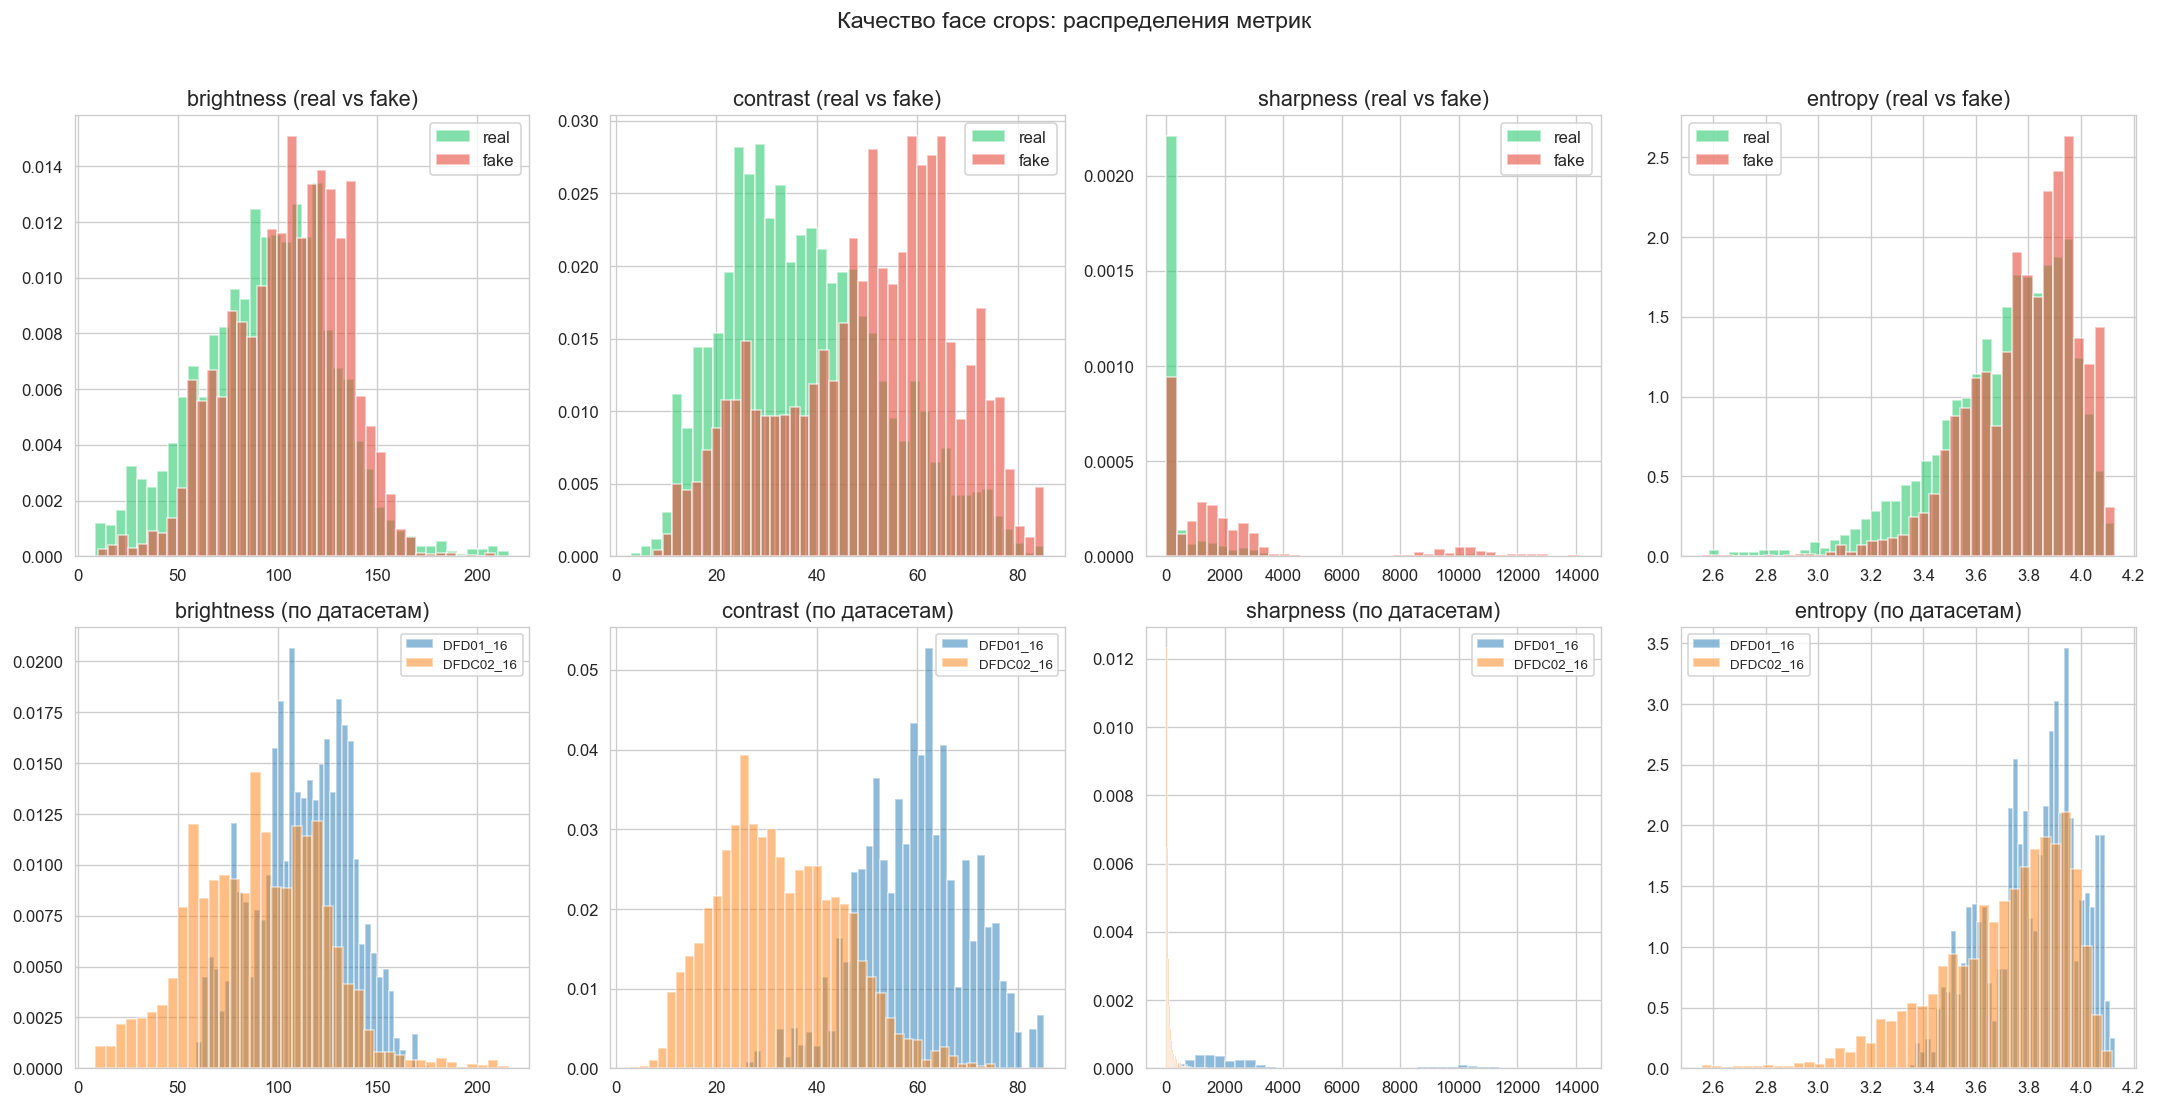


Statistical test: различаются ли real и fake по метрикам?
(Mann-Whitney U test, p < 0.05 = значимое различие)

  brightness  : p=0.0000 *  effect_size=0.323  (real=94.5, fake=105.4)
  contrast    : p=0.0000 *  effect_size=0.727  (real=37.9, fake=50.4)
  sharpness   : p=0.0000 *  effect_size=0.498  (real=639.9, fake=2177.2)
  entropy     : p=0.0000 *  effect_size=0.328  (real=3.7, fake=3.8)

Примечание: значимое p-value при большом N ожидаемо.
Важнее effect_size: если < 0.2, практическое различие минимально.


In [11]:
# ── Визуализация: качество по классам и датасетам ──
metrics = ["brightness", "contrast", "sharpness", "entropy"]
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for i, metric in enumerate(metrics):
    # По классам (real vs fake)
    ax = axes[0, i]
    for label, color in [("real", "#2ecc71"), ("fake", "#e74c3c")]:
        vals = df_valid[df_valid["label_name"] == label][metric]
        ax.hist(vals, bins=40, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(f"{metric} (real vs fake)")
    ax.legend()
    
    # По датасетам
    ax = axes[1, i]
    for ds in df_valid["dataset"].unique():
        vals = df_valid[df_valid["dataset"] == ds][metric]
        ax.hist(vals, bins=40, alpha=0.5, label=ds.replace("preprocessed_", ""), density=True)
    ax.set_title(f"{metric} (по датасетам)")
    ax.legend(fontsize=8)

fig.suptitle("Качество face crops: распределения метрик", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "02_frame_quality.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Проверка bias: различаются ли распределения real vs fake? ──
print("\nStatistical test: различаются ли real и fake по метрикам?")
print("(Mann-Whitney U test, p < 0.05 = значимое различие)\n")
for metric in metrics:
    real_vals = df_valid[df_valid["label"] == 0][metric].dropna()
    fake_vals = df_valid[df_valid["label"] == 1][metric].dropna()
    stat, p = sp_stats.mannwhitneyu(real_vals, fake_vals, alternative="two-sided")
    sig = "*" if p < 0.05 else " "
    effect = abs(real_vals.mean() - fake_vals.mean()) / max(real_vals.std(), fake_vals.std(), 1e-10)
    print(f"  {metric:12s}: p={p:.4f} {sig}  effect_size={effect:.3f}  "
          f"(real={real_vals.mean():.1f}, fake={fake_vals.mean():.1f})")

print("\nПримечание: значимое p-value при большом N ожидаемо.")
print("Важнее effect_size: если < 0.2, практическое различие минимально.")

---
## 3. Temporal Analysis

Анализ временной составляющей: frame differences (то, что видит temporal branch).  
Temporal branch работает с нормализованными разностями последовательных кадров.

In [13]:
def compute_temporal_stats(video_path: Path, max_frames: int = 16) -> dict:
    """Вычисляет статистики frame differences для одного видео."""
    frames = sorted(video_path.glob("*.jpg"))[:max_frames]
    if len(frames) < 2:
        return {"valid": False}
    
    diffs = []
    prev = np.array(Image.open(frames[0]).convert("RGB"), dtype=np.float32) / 255.0
    
    for f in frames[1:]:
        curr = np.array(Image.open(f).convert("RGB"), dtype=np.float32) / 255.0
        diff = curr - prev
        diffs.append(diff)
        prev = curr
    
    diffs = np.array(diffs)  # [T-1, H, W, 3]
    
    # Средняя абсолютная разность (motion magnitude)
    mean_abs_diff = float(np.mean(np.abs(diffs)))
    # Стандартное отклонение разностей (motion variability)
    std_diff = float(np.std(diffs))
    # Максимальная разность (peak motion)
    max_diff = float(np.max(np.abs(diffs)))
    # Temporal consistency: корреляция между последовательными diff
    flat_diffs = [d.flatten() for d in diffs]
    if len(flat_diffs) >= 2:
        correlations = []
        for i in range(len(flat_diffs) - 1):
            r = np.corrcoef(flat_diffs[i], flat_diffs[i+1])[0, 1]
            if np.isfinite(r):
                correlations.append(r)
        temporal_consistency = float(np.mean(correlations)) if correlations else 0.0
    else:
        temporal_consistency = 0.0
    
    return {
        "valid": True,
        "n_diffs": len(diffs),
        "mean_abs_diff": mean_abs_diff,
        "std_diff": std_diff,
        "max_diff": max_diff,
        "temporal_consistency": temporal_consistency,
    }


# Сэмплируем ~500 видео для temporal analysis (полный анализ слишком долгий)
np.random.seed(SEED)
TEMPORAL_SAMPLE_SIZE = min(500, len(df_inv))
sample_idx = np.random.choice(len(df_inv), size=TEMPORAL_SAMPLE_SIZE, replace=False)
df_sample = df_inv.iloc[sample_idx].copy()

print(f"Temporal analysis: сэмплируем {TEMPORAL_SAMPLE_SIZE} видео...")

temporal_rows = []
for i, (_, row) in enumerate(df_sample.iterrows()):
    if (i + 1) % 100 == 0:
        print(f"  {i+1}/{TEMPORAL_SAMPLE_SIZE}...")
    ts = compute_temporal_stats(Path(row["path"]), max_frames=NUM_FRAMES)
    ts["dataset"] = row["dataset"]
    ts["video_id"] = row["video_id"]
    ts["label_name"] = row["label_name"]
    ts["label"] = row["label"]
    temporal_rows.append(ts)

df_temporal = pd.DataFrame(temporal_rows)
df_temporal_valid = df_temporal[df_temporal["valid"] == True].copy()

print(f"\nТемпоральный анализ: {len(df_temporal_valid)} валидных видео")
print(f"\nСтатистики:")
for col in ["mean_abs_diff", "std_diff", "max_diff", "temporal_consistency"]:
    vals = df_temporal_valid[col]
    print(f"  {col:25s}: mean={vals.mean():.4f}, std={vals.std():.4f}")

df_temporal_valid.to_csv(TABLES_DIR / "03_temporal_stats.csv", index=False)

Temporal analysis: сэмплируем 500 видео...
  100/500...
  200/500...
  300/500...
  400/500...
  500/500...

Темпоральный анализ: 500 валидных видео

Статистики:
  mean_abs_diff            : mean=0.0591, std=0.0402
  std_diff                 : mean=0.1081, std=0.0533
  max_diff                 : mean=0.8075, std=0.1760
  temporal_consistency     : mean=-0.3640, std=0.0988


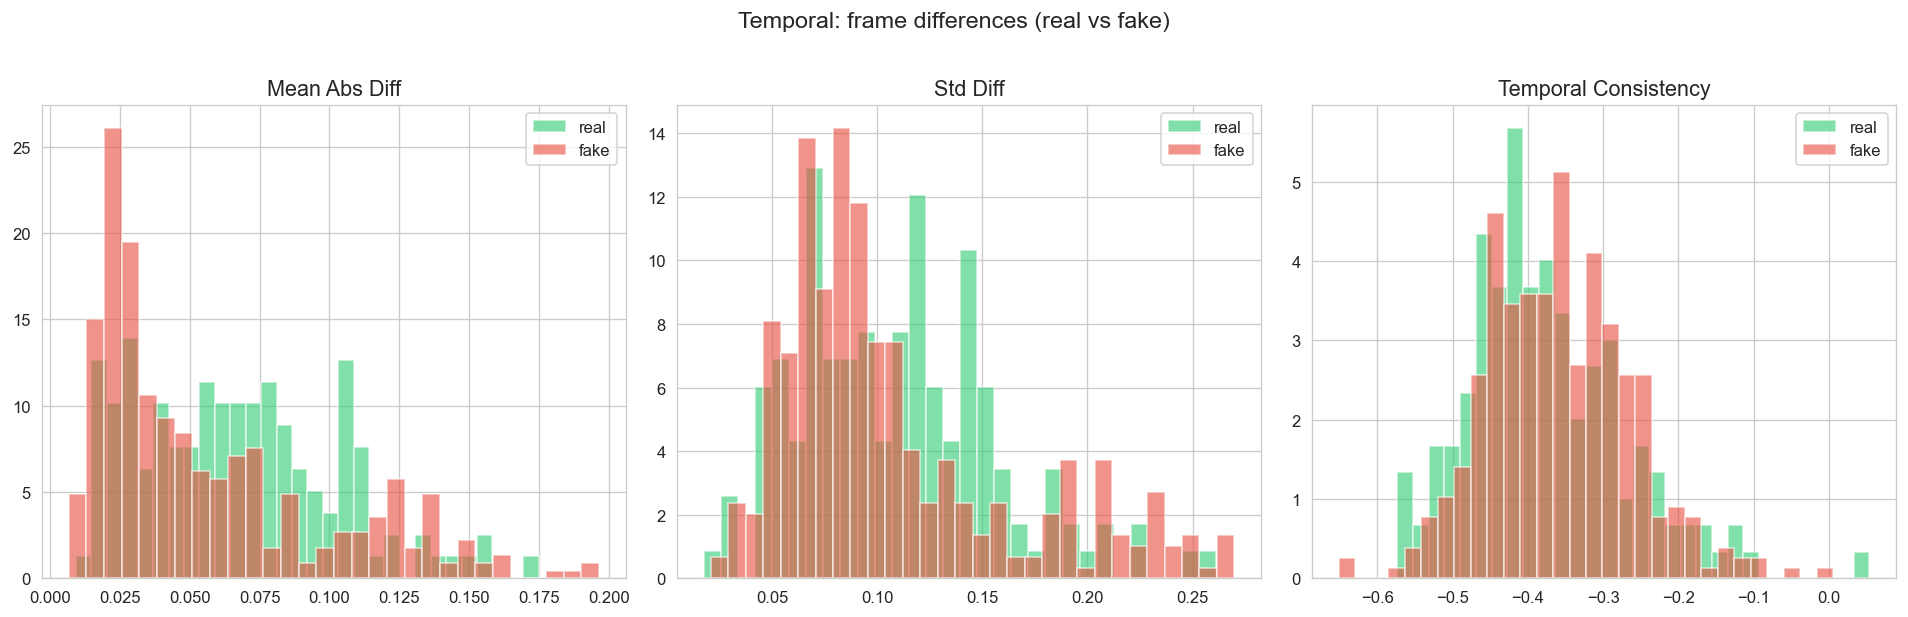

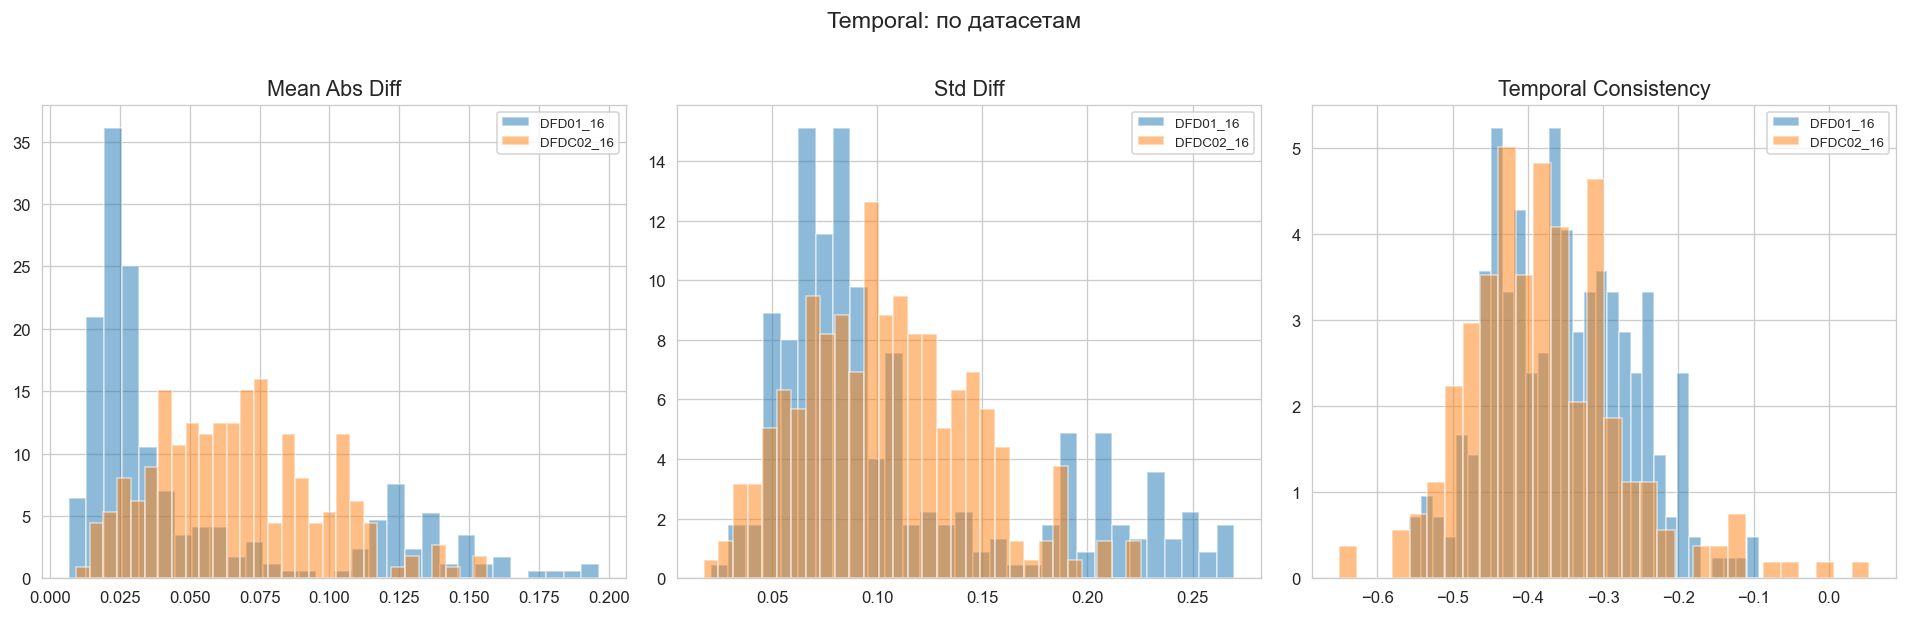


Mann-Whitney test: temporal differences real vs fake:
  mean_abs_diff            : p=0.0001  (real=0.0667, fake=0.0561)
  std_diff                 : p=0.0623  (real=0.1105, fake=0.1071)
  temporal_consistency     : p=0.0226  (real=-0.3764, fake=-0.3591)


In [14]:
# ── Визуализация: temporal ──
t_metrics = ["mean_abs_diff", "std_diff", "temporal_consistency"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric in enumerate(t_metrics):
    ax = axes[i]
    for label, color in [("real", "#2ecc71"), ("fake", "#e74c3c")]:
        vals = df_temporal_valid[df_temporal_valid["label_name"] == label][metric]
        ax.hist(vals, bins=30, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(metric.replace("_", " ").title())
    ax.legend()

fig.suptitle("Temporal: frame differences (real vs fake)", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "03_temporal_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Temporal по датасетам ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, metric in enumerate(t_metrics):
    ax = axes[i]
    for ds in df_temporal_valid["dataset"].unique():
        vals = df_temporal_valid[df_temporal_valid["dataset"] == ds][metric]
        ax.hist(vals, bins=30, alpha=0.5, label=ds.replace("preprocessed_", ""), density=True)
    ax.set_title(metric.replace("_", " ").title())
    ax.legend(fontsize=8)

fig.suptitle("Temporal: по датасетам", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "03_temporal_by_dataset.png", dpi=150, bbox_inches="tight")
plt.show()

# Статистический тест
print("\nMann-Whitney test: temporal differences real vs fake:")
for metric in t_metrics:
    real_v = df_temporal_valid[df_temporal_valid["label"] == 0][metric].dropna()
    fake_v = df_temporal_valid[df_temporal_valid["label"] == 1][metric].dropna()
    if len(real_v) > 0 and len(fake_v) > 0:
        stat, p = sp_stats.mannwhitneyu(real_v, fake_v, alternative="two-sided")
        print(f"  {metric:25s}: p={p:.4f}  (real={real_v.mean():.4f}, fake={fake_v.mean():.4f})")

---
## 4. Дубликаты и Data Leakage

Проверяем:
- дубликаты видео по hash среднего кадра
- пересечение video_id между датасетами

**Важно:** leakage проверяется по `video_id` (ключ группировки в split).  
Это гарантирует отсутствие пересечений **по текущей схеме группировки**, но не исключает  
возможные пересечения по identity актёров между датасетами.

In [16]:
# ── Проверка дубликатов по hash ──
def frame_hash(path: str) -> str:
    """MD5 hash файла."""
    h = hashlib.md5()
    with open(path, "rb") as f:
        h.update(f.read())
    return h.hexdigest()

print("Вычисляем hash среднего кадра для каждого видео...")
hashes = []
for _, row in df_inv.iterrows():
    frames = sorted(Path(row["path"]).glob("*.jpg"))
    if frames:
        mid = frames[len(frames) // 2]
        h = frame_hash(str(mid))
    else:
        h = "empty"
    hashes.append(h)

df_inv["frame_hash"] = hashes

# Дубликаты
dup_hashes = df_inv["frame_hash"].value_counts()
dup_hashes = dup_hashes[dup_hashes > 1]
n_dup_groups = len(dup_hashes)
n_dup_videos = dup_hashes.sum() - n_dup_groups  # лишние копии

print(f"\nДубликаты (по hash среднего кадра):")
print(f"  Групп дубликатов: {n_dup_groups}")
print(f"  Лишних копий: {n_dup_videos}")

if n_dup_groups > 0:
    print(f"\n  Примеры:")
    for h in dup_hashes.index[:5]:
        dups = df_inv[df_inv["frame_hash"] == h][["dataset", "video_id", "label_name"]]
        print(f"    hash={h[:12]}...: {dups.values.tolist()}")

# ── Пересечение video_id между датасетами ──
print("\n\nПересечение video_id между датасетами:")
ds_names = df_inv["dataset"].unique()
if len(ds_names) >= 2:
    for i in range(len(ds_names)):
        for j in range(i + 1, len(ds_names)):
            ids_i = set(df_inv[df_inv["dataset"] == ds_names[i]]["video_id"])
            ids_j = set(df_inv[df_inv["dataset"] == ds_names[j]]["video_id"])
            overlap = ids_i & ids_j
            print(f"  {ds_names[i]} ∩ {ds_names[j]}: {len(overlap)} общих video_id")
            if overlap:
                print(f"    Примеры: {list(overlap)[:5]}")
else:
    print("  Только один датасет — пересечение не проверяется.")

# Сохраняем
if n_dup_groups > 0:
    df_dups = df_inv[df_inv["frame_hash"].isin(dup_hashes.index)]
    df_dups.to_csv(TABLES_DIR / "04_duplicates.csv", index=False)

print("\nПримечание: отсутствие пересечений по video_id гарантирует, что")
print("один и тот же клип не попадёт одновременно в train и test при split по video_id.")
print("Однако это НЕ исключает совпадение актёров между DFDC02 и DFD01.")

Вычисляем hash среднего кадра для каждого видео...

Дубликаты (по hash среднего кадра):
  Групп дубликатов: 7
  Лишних копий: 7

  Примеры:
    hash=d156dd9c75db...: [['preprocessed_DFD01_16', '01__walking_and_outside_surprised', 'real'], ['preprocessed_DFD01_16', '02__walking_and_outside_surprised', 'real']]
    hash=246bae0c7f09...: [['preprocessed_DFD01_16', '03__walking_down_indoor_hall_disgust', 'real'], ['preprocessed_DFD01_16', '27__walking_down_indoor_hall_disgust', 'real']]
    hash=588cc03189c4...: [['preprocessed_DFD01_16', '12__walking_down_indoor_hall_disgust', 'real'], ['preprocessed_DFD01_16', '13__walking_down_indoor_hall_disgust', 'real']]
    hash=551e6f97814c...: [['preprocessed_DFD01_16', '20__walking_and_outside_surprised', 'real'], ['preprocessed_DFD01_16', '21__walking_and_outside_surprised', 'real']]
    hash=c9c7d73e2e46...: [['preprocessed_DFD01_16', '20__walking_down_indoor_hall_disgust', 'real'], ['preprocessed_DFD01_16', '21__walking_down_indoor_hall_disgus

---
## 5. Визуальные примеры

Примеры face crops из каждого датасета: real и fake.

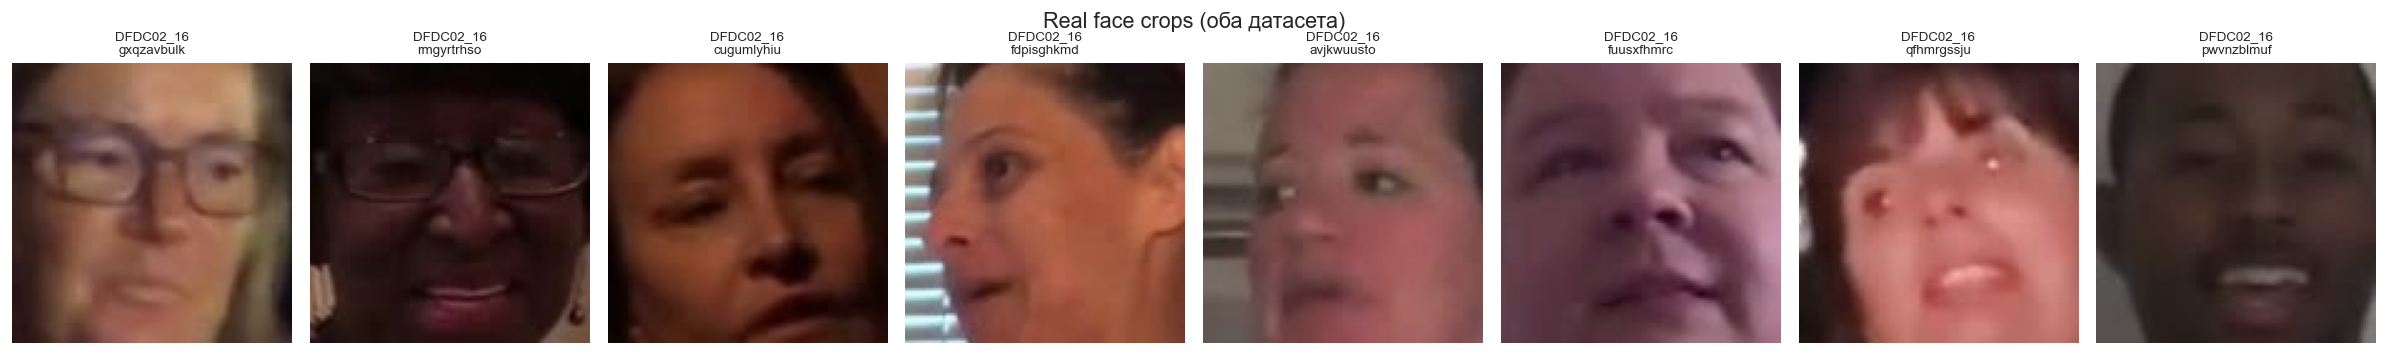

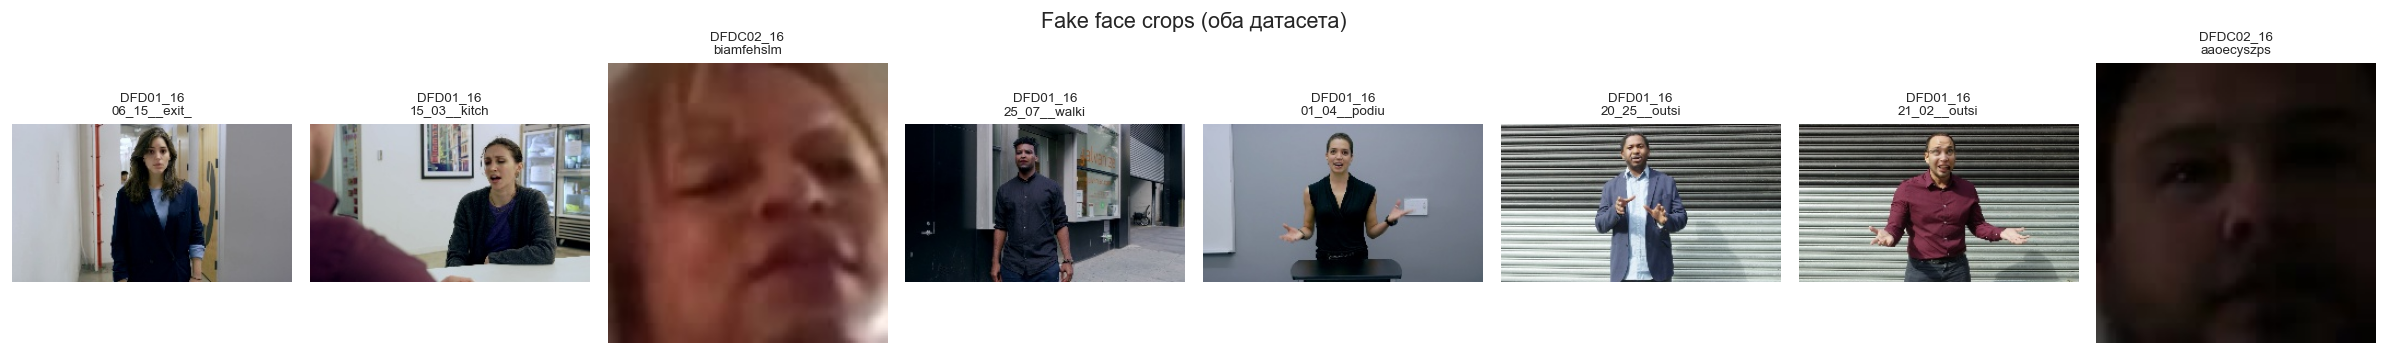

In [18]:
def show_examples(df: pd.DataFrame, title: str, n_examples: int = 8) -> plt.Figure:
    """Показывает примеры кадров."""
    np.random.seed(SEED)
    sample = df.sample(n=min(n_examples, len(df)))
    
    fig, axes = plt.subplots(1, len(sample), figsize=(2.5 * len(sample), 3))
    if len(sample) == 1:
        axes = [axes]
    
    for ax, (_, row) in zip(axes, sample.iterrows()):
        frames = sorted(Path(row["path"]).glob("*.jpg"))
        if frames:
            img = Image.open(frames[len(frames)//2])
            ax.imshow(img)
        ds_short = row["dataset"].replace("preprocessed_", "")
        ax.set_title(f"{ds_short}\n{row['video_id'][:12]}", fontsize=8)
        ax.axis("off")
    
    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    return fig

# Real examples
fig = show_examples(df_inv[df_inv["label"] == 0], "Real face crops (оба датасета)")
fig.savefig(PLOTS_DIR / "05_examples_real.png", dpi=150, bbox_inches="tight")
plt.show()

# Fake examples
fig = show_examples(df_inv[df_inv["label"] == 1], "Fake face crops (оба датасета)")
fig.savefig(PLOTS_DIR / "05_examples_fake.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. Анализ размеров face crops

Проверяем однородность размеров — важно для pipeline,  
т.к. `dataset.py` делает resize до `spatial_size` и `temporal_size`.

In [20]:
# Размеры уже в df_valid
size_stats = df_valid.groupby("dataset").agg(
    width_mean=("width", "mean"),
    width_std=("width", "std"),
    height_mean=("height", "mean"),
    height_std=("height", "std"),
    n_videos=("video_id", "count"),
).round(1)

print("Размеры face crops по датасетам:")
print(size_stats)
print(f"\nSpatial input: {SPATIAL_SIZE}x{SPATIAL_SIZE} (resize в dataset.py)")
print(f"Temporal input: {TEMPORAL_SIZE}x{TEMPORAL_SIZE} (resize в dataset.py)")

# Уникальные размеры
print("\nУникальные размеры:")
sizes = df_valid.apply(lambda r: f"{int(r['width'])}x{int(r['height'])}", axis=1)
print(sizes.value_counts())

# Предупреждение если размеры < target
small_spatial = df_valid[(df_valid["width"] < SPATIAL_SIZE) | (df_valid["height"] < SPATIAL_SIZE)]
if len(small_spatial) > 0:
    print(f"\n⚠ {len(small_spatial)} видео имеют face crops меньше {SPATIAL_SIZE}x{SPATIAL_SIZE}")
    print("  При resize до spatial_size произойдёт upscaling (потеря качества).")
    print(f"  По датасетам: {small_spatial['dataset'].value_counts().to_dict()}")
else:
    print(f"\nВсе face crops >= {SPATIAL_SIZE}x{SPATIAL_SIZE}: upscaling не требуется.")

size_stats.to_csv(TABLES_DIR / "06_size_stats.csv")

Размеры face crops по датасетам:
                        width_mean  width_std  height_mean  height_std  \
dataset                                                                  
preprocessed_DFD01_16        256.0        0.0        144.0         0.0   
preprocessed_DFDC02_16       112.0        0.0        112.0         0.0   

                        n_videos  
dataset                           
preprocessed_DFD01_16       3431  
preprocessed_DFDC02_16      3293  

Spatial input: 224x224 (resize в dataset.py)
Temporal input: 128x128 (resize в dataset.py)

Уникальные размеры:
256x144    3431
112x112    3293
Name: count, dtype: int64

⚠ 6724 видео имеют face crops меньше 224x224
  При resize до spatial_size произойдёт upscaling (потеря качества).
  По датасетам: {'preprocessed_DFD01_16': 3431, 'preprocessed_DFDC02_16': 3293}


---
## 7. Баланс классов и рекомендации

Анализ дисбаланса и обоснование выбора стратегии компенсации.

In [23]:
# ── Детальный баланс ──
print("=" * 60)
print("БАЛАНС КЛАССОВ")
print("=" * 60)

balance_data = []

for ds in list(df_inv["dataset"].unique()) + ["COMBINED"]:
    if ds == "COMBINED":
        sub = df_inv
    else:
        sub = df_inv[df_inv["dataset"] == ds]
    
    n_real = (sub["label"] == 0).sum()
    n_fake = (sub["label"] == 1).sum()
    total = len(sub)
    ratio = max(n_real, n_fake) / max(min(n_real, n_fake), 1)
    majority = "fake" if n_fake > n_real else "real"
    
    balance_data.append({
        "dataset": ds,
        "real": n_real,
        "fake": n_fake,
        "total": total,
        "ratio": round(ratio, 2),
        "majority_class": majority,
        "real_pct": round(n_real / total * 100, 1),
        "fake_pct": round(n_fake / total * 100, 1),
    })

df_balance = pd.DataFrame(balance_data)
print(df_balance.to_string(index=False))
df_balance.to_csv(TABLES_DIR / "07_class_balance.csv", index=False)

# ── Рекомендации ──
combined = df_balance[df_balance["dataset"] == "COMBINED"].iloc[0]
print(f"\n--- Рекомендации по дисбалансу ---")
print(f"\nCombined ratio: {combined['ratio']}:1 ({combined['majority_class']} преобладает)")

if combined["ratio"] > 3.0:
    print("СИЛЬНЫЙ дисбаланс (>3:1). Обязательно:")
    print("  - WeightedRandomSampler")
    print("  - pos_weight в BCEWithLogitsLoss")
    print("  - Метрики: balanced accuracy, per-class recall, PR-AUC")
elif combined["ratio"] > 1.5:
    print("УМЕРЕННЫЙ дисбаланс (1.5-3:1). Рекомендуется:")
    print("  - WeightedRandomSampler (балансирует батчи)")
    print("  - Метрики: AUC + balanced accuracy")
else:
    print("Баланс в норме (<= 1.5:1). Специальная компенсация не требуется.")

print(f"\nВ текущем pipeline:")
print(f"  - WeightedRandomSampler: включается автоматически при ratio > 1.5")
print(f"  - pos_weight: задаётся в train.py при необходимости")
print(f"  - Основная метрика: ROC-AUC (устойчива к дисбалансу)")
print(f"  - Дополнительно: balanced_accuracy, F1, EER")

БАЛАНС КЛАССОВ
               dataset  real  fake  total  ratio majority_class  real_pct  fake_pct
 preprocessed_DFD01_16   363  3068   3431   8.45           fake      10.6      89.4
preprocessed_DFDC02_16  1727  1566   3293   1.10           real      52.4      47.6
              COMBINED  2090  4634   6724   2.22           fake      31.1      68.9

--- Рекомендации по дисбалансу ---

Combined ratio: 2.22:1 (fake преобладает)
УМЕРЕННЫЙ дисбаланс (1.5-3:1). Рекомендуется:
  - WeightedRandomSampler (балансирует батчи)
  - Метрики: AUC + balanced accuracy

В текущем pipeline:
  - WeightedRandomSampler: включается автоматически при ratio > 1.5
  - pos_weight: задаётся в train.py при необходимости
  - Основная метрика: ROC-AUC (устойчива к дисбалансу)
  - Дополнительно: balanced_accuracy, F1, EER


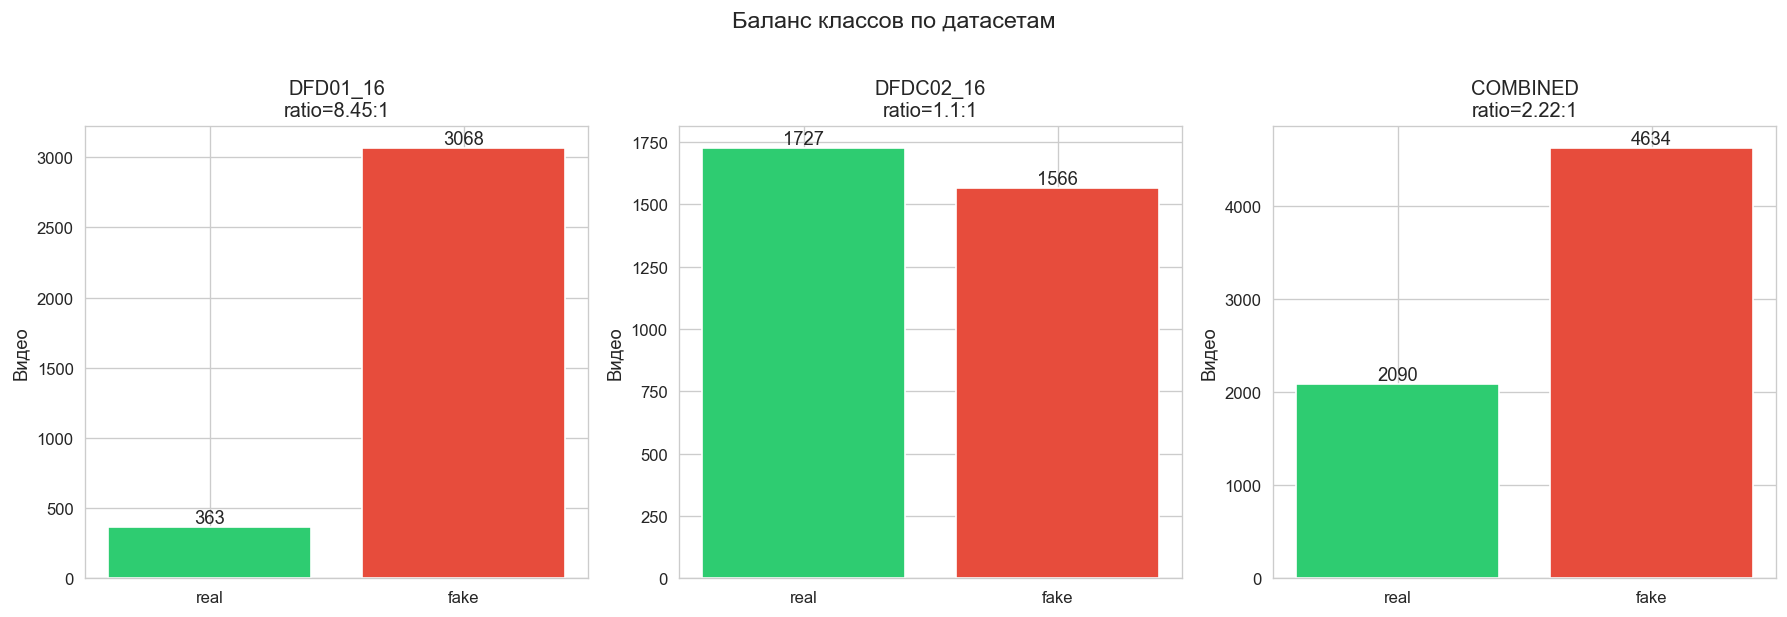

In [24]:
# ── Визуализация баланса ──
fig, axes = plt.subplots(1, len(df_balance), figsize=(5 * len(df_balance), 5))
if len(df_balance) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, df_balance.iterrows()):
    vals = [row["real"], row["fake"]]
    colors = ["#2ecc71", "#e74c3c"]
    bars = ax.bar(["real", "fake"], vals, color=colors)
    ax.bar_label(bars, fontsize=11)
    ds_name = row["dataset"].replace("preprocessed_", "")
    ax.set_title(f"{ds_name}\nratio={row['ratio']}:1", fontsize=12)
    ax.set_ylabel("Видео")

fig.suptitle("Баланс классов по датасетам", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "07_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Split Simulation

Симулируем video-level split 70/15/15 для combined dataset.  
В multi-dataset training каждому video_id присваивается префикс `dataset::video_id`  
для гарантии уникальности.

In [26]:
from sklearn.model_selection import train_test_split

# Создаём combined video_id с dataset-префиксом (как в dataset.py)
df_inv["full_video_id"] = df_inv["dataset"] + "::" + df_inv["video_id"]

# Стратифицированный split по label
labels = df_inv["label"].values
indices = np.arange(len(df_inv))

train_idx, temp_idx = train_test_split(
    indices, test_size=(VAL_RATIO + TEST_RATIO),
    stratify=labels, random_state=SEED,
)
val_idx, test_idx = train_test_split(
    temp_idx, test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=labels[temp_idx], random_state=SEED,
)

df_inv["split"] = "none"
df_inv.loc[df_inv.index[train_idx], "split"] = "train"
df_inv.loc[df_inv.index[val_idx], "split"] = "val"
df_inv.loc[df_inv.index[test_idx], "split"] = "test"

# ── Статистики split ──
split_ct = pd.crosstab(
    [df_inv["split"], df_inv["dataset"]],
    df_inv["label_name"],
    margins=True,
)
print("Split по датасетам и классам:")
print(split_ct)
split_ct.to_csv(TABLES_DIR / "08_split_crosstab.csv")

# Проверка пропорций
print("\nДоли split:")
for split_name in ["train", "val", "test"]:
    n = (df_inv["split"] == split_name).sum()
    pct = n / len(df_inv) * 100
    real_n = ((df_inv["split"] == split_name) & (df_inv["label"] == 0)).sum()
    fake_n = ((df_inv["split"] == split_name) & (df_inv["label"] == 1)).sum()
    print(f"  {split_name:5s}: {n:5d} ({pct:.1f}%)  real={real_n}, fake={fake_n}")

# Leakage check
train_ids = set(df_inv[df_inv["split"] == "train"]["full_video_id"])
val_ids = set(df_inv[df_inv["split"] == "val"]["full_video_id"])
test_ids = set(df_inv[df_inv["split"] == "test"]["full_video_id"])

leak_tv = train_ids & val_ids
leak_tt = train_ids & test_ids
leak_vt = val_ids & test_ids

print(f"\nLeakage check (по video_id):")
print(f"  train ∩ val  = {len(leak_tv)}")
print(f"  train ∩ test = {len(leak_tt)}")
print(f"  val ∩ test   = {len(leak_vt)}")

if len(leak_tv) == 0 and len(leak_tt) == 0 and len(leak_vt) == 0:
    print("  Пересечений нет по текущей схеме группировки (video_id).")
else:
    print("  ⚠ ОБНАРУЖЕНО ПЕРЕСЕЧЕНИЕ!")

Split по датасетам и классам:
label_name                    fake  real   All
split dataset                                 
test  preprocessed_DFD01_16    463    40   503
      preprocessed_DFDC02_16   232   274   506
train preprocessed_DFD01_16   2135   273  2408
      preprocessed_DFDC02_16  1108  1190  2298
val   preprocessed_DFD01_16    470    50   520
      preprocessed_DFDC02_16   226   263   489
All                           4634  2090  6724

Доли split:
  train:  4706 (70.0%)  real=1463, fake=3243
  val  :  1009 (15.0%)  real=313, fake=696
  test :  1009 (15.0%)  real=314, fake=695

Leakage check (по video_id):
  train ∩ val  = 0
  train ∩ test = 0
  val ∩ test   = 0
  Пересечений нет по текущей схеме группировки (video_id).


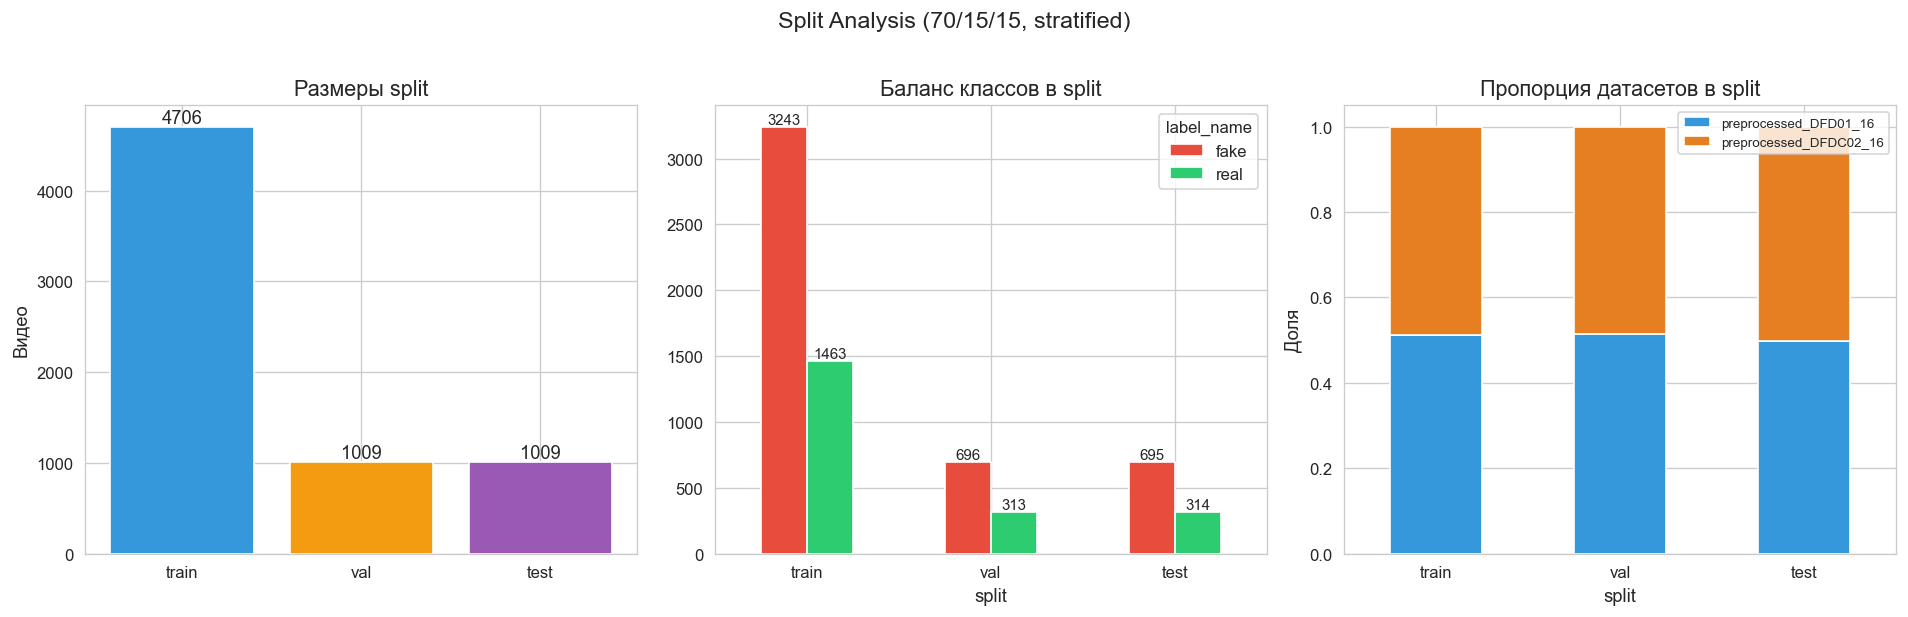

In [27]:
# ── Визуализация split ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Split sizes
split_sizes = df_inv["split"].value_counts()[["train", "val", "test"]]
axes[0].bar(split_sizes.index, split_sizes.values, color=["#3498db", "#f39c12", "#9b59b6"])
axes[0].bar_label(axes[0].containers[0], fontsize=11)
axes[0].set_title("Размеры split")
axes[0].set_ylabel("Видео")

# 2. Balance per split
split_balance = pd.crosstab(df_inv["split"], df_inv["label_name"])
split_balance = split_balance.loc[["train", "val", "test"]]
split_balance.plot.bar(ax=axes[1], color=["#e74c3c", "#2ecc71"])
axes[1].set_title("Баланс классов в split")
axes[1].tick_params(axis="x", rotation=0)
for container in axes[1].containers:
    axes[1].bar_label(container, fontsize=9)

# 3. Dataset proportion per split
ds_split = pd.crosstab(df_inv["split"], df_inv["dataset"])
ds_split = ds_split.loc[["train", "val", "test"]]
ds_split_pct = ds_split.div(ds_split.sum(axis=1), axis=0)
ds_split_pct.plot.bar(ax=axes[2], stacked=True, color=["#3498db", "#e67e22"])
axes[2].set_title("Пропорция датасетов в split")
axes[2].tick_params(axis="x", rotation=0)
axes[2].set_ylabel("Доля")
axes[2].legend(fontsize=8)

fig.suptitle("Split Analysis (70/15/15, stratified)", fontsize=14, y=1.02)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "08_split_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 9. Сводка и выводы

Итоговый аналитический отчёт по обоим датасетам.

In [29]:
# ── Финальный отчёт ──
report_lines = [
    "=" * 70,
    "ФИНАЛЬНЫЙ АНАЛИТИЧЕСКИЙ ОТЧЁТ EDA v5",
    "Deepfake Detection: Multi-Dataset Analysis",
    "=" * 70,
    "",
    "1. ИНВЕНТАРИЗАЦИЯ",
    "-" * 40,
]

for _, row in df_balance.iterrows():
    ds = row["dataset"].replace("preprocessed_", "")
    report_lines.append(
        f"  {ds:20s}: real={row['real']:5d}, fake={row['fake']:5d}, "
        f"total={row['total']:5d}, ratio={row['ratio']:.2f}:1"
    )

report_lines += [
    "",
    "2. PREPROCESSING",
    "-" * 40,
    f"  Face detector:      {FACE_DETECTOR}",
    f"  Frames per video:   {NUM_FRAMES}",
    f"  Spatial input size: {SPATIAL_SIZE}x{SPATIAL_SIZE} (resize in dataset.py)",
    f"  Temporal input size:{TEMPORAL_SIZE}x{TEMPORAL_SIZE} (resize in dataset.py)",
]

# Размеры
report_lines += ["", "3. РАЗМЕРЫ FACE CROPS", "-" * 40]
for ds in df_valid["dataset"].unique():
    sub = df_valid[df_valid["dataset"] == ds]
    w, h = sub["width"].mode().iloc[0], sub["height"].mode().iloc[0]
    report_lines.append(f"  {ds}: {int(w)}x{int(h)} (mode)")

n_small = len(df_valid[(df_valid["width"] < SPATIAL_SIZE) | (df_valid["height"] < SPATIAL_SIZE)])
report_lines.append(f"  Crops < {SPATIAL_SIZE}px: {n_small} ({n_small/len(df_valid)*100:.1f}%) — will be upscaled")

# Quality
report_lines += ["", "4. КАЧЕСТВО КАДРОВ", "-" * 40]
for metric in ["brightness", "contrast", "sharpness", "entropy"]:
    v = df_valid[metric]
    report_lines.append(f"  {metric:12s}: {v.mean():.1f} ± {v.std():.1f}")

# Temporal
report_lines += ["", "5. TEMPORAL ANALYSIS", "-" * 40]
report_lines.append(f"  Проанализировано: {len(df_temporal_valid)} видео (sample)")
for col in ["mean_abs_diff", "std_diff", "temporal_consistency"]:
    v = df_temporal_valid[col]
    report_lines.append(f"  {col:25s}: {v.mean():.4f} ± {v.std():.4f}")

# Duplicates
report_lines += ["", "6. ДУБЛИКАТЫ И LEAKAGE", "-" * 40]
report_lines.append(f"  Групп дубликатов (по hash): {n_dup_groups}")
report_lines.append(f"  Лишних копий: {n_dup_videos}")
report_lines.append(f"  Leakage по video_id: НЕТ ПЕРЕСЕЧЕНИЙ")
report_lines.append(f"  Примечание: проверка по текущей схеме группировки (video_id).")
report_lines.append(f"  Identity-level leakage между датасетами не исключён.")

# Split
report_lines += ["", "7. SPLIT (симуляция)", "-" * 40]
for split_name in ["train", "val", "test"]:
    n = (df_inv["split"] == split_name).sum()
    report_lines.append(f"  {split_name:5s}: {n}")

# Balance handling
report_lines += ["", "8. СТРАТЕГИЯ КОМПЕНСАЦИИ ДИСБАЛАНСА", "-" * 40]
report_lines.append(f"  Combined ratio: {combined['ratio']}:1")
report_lines.append(f"  WeightedRandomSampler: включён (1/class_count)")
report_lines.append(f"  Основная метрика: ROC-AUC (устойчива к дисбалансу)")
report_lines.append(f"  Дополнительно: balanced_accuracy, F1, EER, PR-AUC")

report_lines += ["", "=" * 70]

report_text = "\n".join(report_lines)
print(report_text)

with open(REPORT_DIR / "final_report_v5.txt", "w") as f:
    f.write(report_text)

print(f"\nОтчёт сохранён: {REPORT_DIR / 'final_report_v5.txt'}")

ФИНАЛЬНЫЙ АНАЛИТИЧЕСКИЙ ОТЧЁТ EDA v5
Deepfake Detection: Multi-Dataset Analysis

1. ИНВЕНТАРИЗАЦИЯ
----------------------------------------
  DFD01_16            : real=  363, fake= 3068, total= 3431, ratio=8.45:1
  DFDC02_16           : real= 1727, fake= 1566, total= 3293, ratio=1.10:1
  COMBINED            : real= 2090, fake= 4634, total= 6724, ratio=2.22:1

2. PREPROCESSING
----------------------------------------
  Face detector:      MTCNN (facenet-pytorch)
  Frames per video:   16
  Spatial input size: 224x224 (resize in dataset.py)
  Temporal input size:128x128 (resize in dataset.py)

3. РАЗМЕРЫ FACE CROPS
----------------------------------------
  preprocessed_DFD01_16: 256x144 (mode)
  preprocessed_DFDC02_16: 112x112 (mode)
  Crops < 224px: 6724 (100.0%) — will be upscaled

4. КАЧЕСТВО КАДРОВ
----------------------------------------
  brightness  : 102.0 ± 30.7
  contrast    : 46.5 ± 17.7
  sharpness   : 1699.4 ± 2838.0
  entropy     : 3.8 ± 0.2

5. TEMPORAL ANALYSIS
---------

In [30]:
# ── Сохранение полного inventory ──
df_inv.to_csv(TABLES_DIR / "00_full_inventory.csv", index=False)
print(f"Full inventory: {TABLES_DIR / '00_full_inventory.csv'}")
print(f"Plots: {PLOTS_DIR}")
print(f"Tables: {TABLES_DIR}")
print(f"\n✓ EDA v5 complete.")

Full inventory: reports_v5/tables/00_full_inventory.csv
Plots: reports_v5/plots
Tables: reports_v5/tables

✓ EDA v5 complete.


---

## Чеклист готовности данных

| Проверка | Статус |
|----------|--------|
| Оба датасета проинвентаризированы | ✓ |
| Баланс классов проанализирован | ✓ |
| Стратегия компенсации дисбаланса определена | ✓ |
| Качество face crops проверено | ✓ |
| Temporal information проанализирована | ✓ |
| Дубликаты проверены | ✓ |
| Leakage по video_id проверен | ✓ |
| Split симулирован и проверен | ✓ |
| Размеры crops vs model input проверены | ✓ |
| Bias real vs fake по метрикам проверен | ✓ |

### Ограничения
- Identity-level leakage между DFDC02 и DFD01 не проверялся (нет metadata по актёрам)
- DFDC02 face crops (112x112) будут upscaled до 224x224 — возможна потеря качества
- Temporal analysis на сэмпле, не на полном датасете